----------------


In this notebook we are going to see how the preprocessing which is the first step of our project is done.

There are several steps which were seperately run and condensed the whole code into a single cell after tesing and running different options.

After preprocessing, we did the cross-checking of dataset we got, whether it is genuine, whether it has any null values etc, and did some visualisation which will be explained later on.


In [ ]:
#importing the libraries which are necessary for the operations we do below


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from statsmodels.tsa.stattools import acf
import seaborn as sns

We start the actual preprocessing in this cell, in the below cellthe whole preprcessing done in one cell but it has many steps

In [ ]:
#  Below are two functions which we will use later to call, so we defined them earlier on

# --- Helper Functions ---

# the significance of this fucntion is that the time is not stricly increasing,
# as in if you take a bee for eg: Bee24; the whole recording data of this bee has intervals meaning the recording reset, 
# they might be ranging from few secs to few min of recording which is data.
# so we want this to be increasing, to make that happen when ever there is a reset in time we clip it and add the difference from the previous time to the new time so that they are now linearly increasing

def fix_time_resets(time_array):
    fixed_time = time_array.copy()
    offset = 0.0
    for i in range(1, len(time_array)):
        if time_array[i] < time_array[i - 1]:
            offset += time_array[i - 1]
        fixed_time[i] += offset
    return fixed_time

# we need to do autocorrelation to decide whether the segments of data are worth keeping or not
# we compute a threshold to decide that

def compute_autocorrelation_lag(signal, dt, threshold=0.3, max_lag_seconds=5):
    nlags = int(max_lag_seconds / dt)
    autocorr = acf(signal - np.mean(signal), nlags=nlags, fft=True)
    for lag in range(1, len(autocorr)):
        if autocorr[lag] < threshold:
            return lag * dt
    return max_lag_seconds


# below is the main section of the code for preprocessing


# we have 52 files of each individual bee as a file, we are going to scan them individually and extract the required columns which we need and merge them into a new dataset for further analysis

# --- Processing Loop ---
all_dfs = []
dt = 1 / 30   #sampling rate
data_folder = "data_raw"

for bee_index in range(1, 53):  # Bee1.xlsx to Bee52.xlsx
    filename = f"Bee{bee_index}.xlsx"
    filepath = os.path.join(data_folder, filename)
    bee_id = f"Bee{bee_index}"

    print(f"Processing: {filepath}")
    df = pd.read_excel(filepath)


    # we are going to use just 4 columns from the 52 files which are time, x,y and z and then we are going to interpolated them
    # and using the interpoalted data we are going to derive the velocity, tortuosity and angular change 

    derived_columns = ['velocityX', 'velocityY', 'velocityZ', 'tort_Xy', 'tort_Xz', 'ang_ch_Xv', 'ang_ch_Xy', 'ang_ch_Xz']
    selected_columns = ['time', 'x', 'y', 'z'] + [col for col in derived_columns if col in df.columns]
    df = df[selected_columns].copy()

    df['fixed_time'] = fix_time_resets(df['time'].values)
    df['time_diff'] = df['fixed_time'].diff()
    df = df.dropna().drop_duplicates(subset='fixed_time').sort_values('fixed_time')

    estimated_max_gap = compute_autocorrelation_lag(df['x'].dropna().values, dt)

    # Segmenting
    
    # we did this process in segments cause the data is so huge that we might loose some information if we did all at once
    
    segments = []
    current_segment = [0]
    for i in range(1, len(df)):
        if df['fixed_time'].iloc[i] - df['fixed_time'].iloc[i - 1] <= estimated_max_gap:
            current_segment.append(i)
        else:
            if len(current_segment) > 3:
                segments.append(current_segment)
            current_segment = [i]
    if len(current_segment) > 3:
        segments.append(current_segment)




    # Interpolation and Feature Computation

    # we did cubic spline interpolation to fill the gaps of missing data 
    interp_dfs = []
    for seg in segments:
        sub_df = df.iloc[seg]
        time = sub_df['fixed_time'].to_numpy()
        x = sub_df['x'].to_numpy()
        y = sub_df['y'].to_numpy()
        z = sub_df['z'].to_numpy()

        if len(time) < 4:
            continue

        time_uniform = np.arange(time.min(), time.max(), dt)
        x_interp = CubicSpline(time, x)(time_uniform)
        y_interp = CubicSpline(time, y)(time_uniform)
        z_interp = CubicSpline(time, z)(time_uniform)

        vx = np.gradient(x_interp, dt)
        vy = np.gradient(y_interp, dt)
        vz = np.gradient(z_interp, dt)

        tort_xy = np.zeros_like(x_interp)
        tort_xz = np.zeros_like(x_interp)
        ang_x = np.zeros_like(x_interp)
        ang_xy = np.zeros_like(x_interp)
        ang_xz = np.zeros_like(x_interp)


        for i in range(1, len(x_interp) - 1):
            # Tortuosity
            d1_xy = np.linalg.norm([x_interp[i] - x_interp[i - 1], y_interp[i] - y_interp[i - 1]])
            d2_xy = np.linalg.norm([x_interp[i + 1] - x_interp[i], y_interp[i + 1] - y_interp[i]])
            d_str_xy = np.linalg.norm([x_interp[i + 1] - x_interp[i - 1], y_interp[i + 1] - y_interp[i - 1]])
            tort_xy[i] = (d1_xy + d2_xy) / d_str_xy if d_str_xy else 0

            d1_xz = np.linalg.norm([x_interp[i] - x_interp[i - 1], z_interp[i] - z_interp[i - 1]])
            d2_xz = np.linalg.norm([x_interp[i + 1] - x_interp[i], z_interp[i + 1] - z_interp[i]])
            d_str_xz = np.linalg.norm([x_interp[i + 1] - x_interp[i - 1], z_interp[i + 1] - z_interp[i - 1]])
            tort_xz[i] = (d1_xz + d2_xz) / d_str_xz if d_str_xz else 0

            # Angular change
            v1 = np.array([x_interp[i] - x_interp[i - 1], y_interp[i] - y_interp[i - 1], z_interp[i] - z_interp[i - 1]])
            v2 = np.array([x_interp[i + 1] - x_interp[i], y_interp[i + 1] - y_interp[i], z_interp[i + 1] - z_interp[i]])
            ang_x[i] = np.arccos(np.clip(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-8), -1, 1))
            ang_xy[i] = np.arccos(np.clip(np.dot(v1[:2], v2[:2]) / (np.linalg.norm(v1[:2]) * np.linalg.norm(v2[:2]) + 1e-8), -1, 1))
            ang_xz[i] = np.arccos(np.clip(np.dot(v1[[0, 2]], v2[[0, 2]]) / (np.linalg.norm(v1[[0, 2]]) * np.linalg.norm(v2[[0, 2]]) + 1e-8), -1, 1))

        interp_dfs.append(pd.DataFrame({
            'bee_id': bee_id,
            'time': time_uniform,
            'x': x_interp,
            'y': y_interp,
            'z': z_interp,
            'velocityX': np.round(vx, 2),
            'velocityY': np.round(vy, 2),
            'velocityZ': np.round(vz, 2),
            'tort_Xy': np.round(tort_xy, 2),
            'tort_Xz': np.round(tort_xz, 2),
            'ang_ch_Xv': np.round(ang_x, 2),
            'ang_ch_Xy': np.round(ang_xy, 2),
            'ang_ch_Xz': np.round(ang_xz, 2)
        }))

    all_dfs.extend(interp_dfs)

# --- Final Merge and Save ---
df_merged = pd.concat(all_dfs, ignore_index=True)
df_merged.to_csv('processed_bee_data.csv', index=False)
print("Saved merged data to 'processed_bee_data.csv'")

# --- Sample Visualizations ---
sample_bees = df_merged['bee_id'].unique()[:3]
plt.figure(figsize=(14, 6))
for bee in sample_bees:
    sub = df_merged[df_merged['bee_id'] == bee]
    plt.plot(sub['time'], sub['velocityX'], label=f'{bee} - velocityX')
plt.xlabel('Time (s)')
plt.ylabel('Velocity X')
plt.title('Velocity X over Time (Sample Bees)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_merged, x='bee_id', y='tort_Xy')
plt.xticks(rotation=90)
plt.title("Tortuosity XY Distribution by Bee")
plt.tight_layout()
plt.show()


[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


'\n\n# --- Processing Loop ---\nall_dfs = []\ndt = 1 / 30\ndata_folder = "data_raw"\n\nfor bee_index in range(1, 53):  # Bee1.xlsx to Bee52.xlsx\n    filename = f"Bee{bee_index}.xlsx"\n    filepath = os.path.join(data_folder, filename)\n    bee_id = f"Bee{bee_index}"\n\n    print(f"Processing: {filepath}")\n    df = pd.read_excel(filepath)\n\n    derived_columns = [\'velocityX\', \'velocityY\', \'velocityZ\', \'tort_Xy\', \'tort_Xz\', \'ang_ch_Xv\', \'ang_ch_Xy\', \'ang_ch_Xz\']\n    selected_columns = [\'time\', \'x\', \'y\', \'z\'] + [col for col in derived_columns if col in df.columns]\n    df = df[selected_columns].copy()\n\n    df[\'fixed_time\'] = fix_time_resets(df[\'time\'].values)\n    df[\'time_diff\'] = df[\'fixed_time\'].diff()\n    df = df.dropna().drop_duplicates(subset=\'fixed_time\').sort_values(\'fixed_time\')\n\n    estimated_max_gap = compute_autocorrelation_lag(df[\'x\'].dropna().values, dt)\n\n    # Segmenting\n    segments = []\n    current_segment = [0]\n    for 

In [10]:
df_merged=pd.read_csv('processed_bee_data.csv')

In [11]:
df_merged.head()


,bee_id,time,x,y,z,velocityX,velocityY,velocityZ,tort_Xy,tort_Xz,ang_ch_Xv,ang_ch_Xy,ang_ch_Xz
0,Bee1,7.303000,1476.600000,2000.500000,-66.300000,-39.25,39.26,5.98,0.0,0.00,0.00,0.00,0.00
1,Bee1,7.336333,1475.291544,2001.808583,-66.100702,-29.90,29.90,-1.43,1.0,1.04,0.40,0.00,0.56
2,Bee1,7.369667,1474.606825,2002.493429,-66.395073,-23.87,20.87,-13.49,1.0,1.00,0.22,0.12,0.18
3,Bee1,7.403000,1473.700000,2003.200000,-67.000000,-34.82,21.22,-18.15,1.0,1.00,0.22,0.20,0.18
4,Bee1,7.436333,1472.285382,2003.908307,-67.604993,-40.35,25.34,-14.95,1.0,1.00,0.22,0.19,0.11


In [12]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8741009 entries, 0 to 8741008
Data columns (total 13 columns):
 #   Column     Dtype  
---  ------     -----  
 0   bee_id     object 
 1   time       float64
 2   x          float64
 3   y          float64
 4   z          float64
 5   velocityX  float64
 6   velocityY  float64
 7   velocityZ  float64
 8   tort_Xy    float64
 9   tort_Xz    float64
 10  ang_ch_Xv  float64
 11  ang_ch_Xy  float64
 12  ang_ch_Xz  float64
dtypes: float64(12), object(1)
memory usage: 867.0+ MB


In [13]:
df_merged.shape

(8741009, 13)

Below we are plotting a segment of data which we interpolated with the raw data we have to check the authenticity of out interpolation
We took bee1 x,y and z features for this comparison

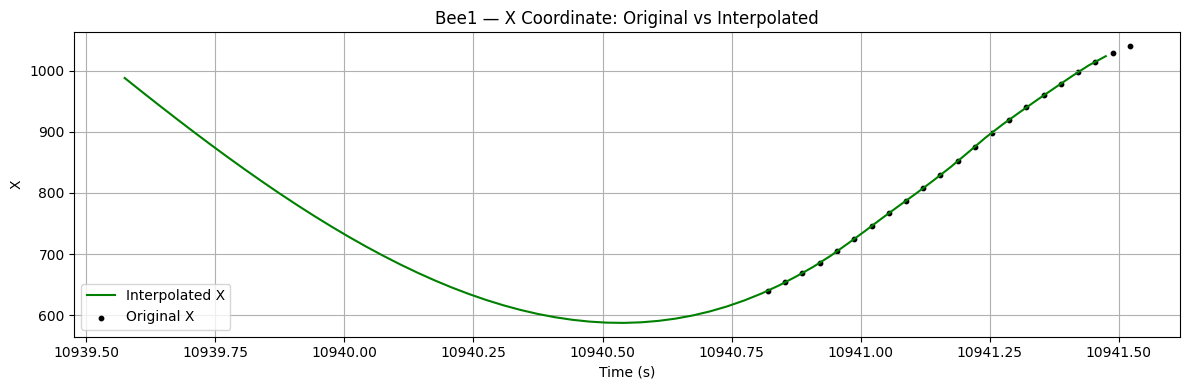

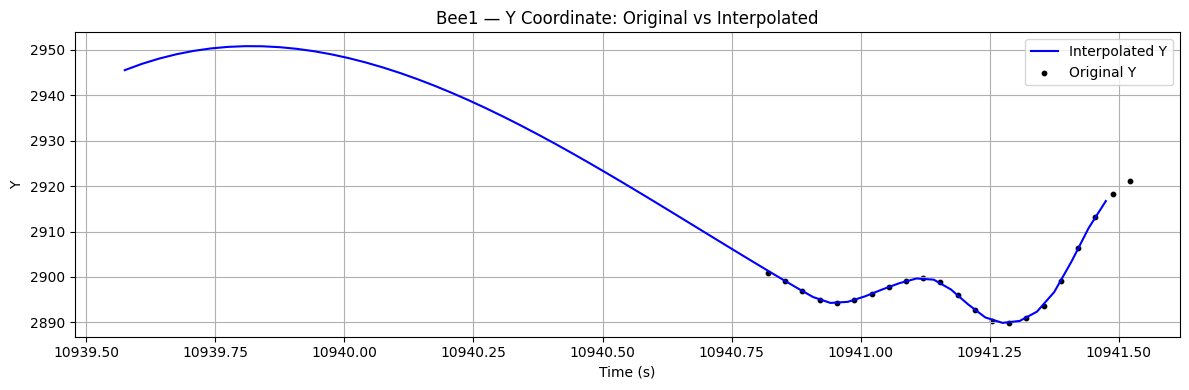

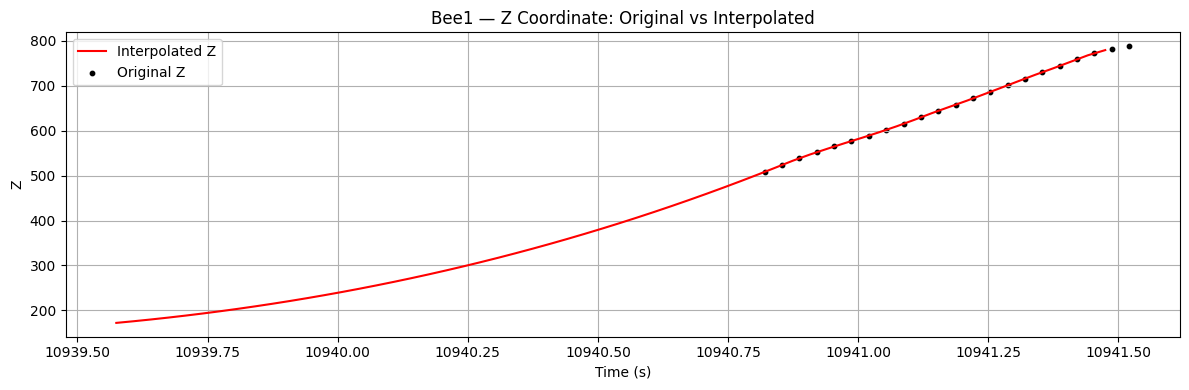

In [ ]:


# Set bee ID
target_bee = 'Bee1'

# Load original data and fix time
original_file = os.path.join('data_raw', f'{target_bee}.xlsx')
df_orig = pd.read_excel(original_file)
df_orig['fixed_time'] = fix_time_resets(df_orig['time'].values)
df_orig = df_orig.dropna(subset=['x', 'y', 'z']).drop_duplicates(subset='fixed_time').sort_values('fixed_time')

# Get interpolated data for the same bee
df_interp = df_merged[df_merged['bee_id'] == target_bee]

# Find overlapping time range
min_t = max(df_orig['fixed_time'].min(), df_interp['time'].min())
max_t = min(df_orig['fixed_time'].max(), df_interp['time'].max())
t_mid = (min_t + max_t) / 2

# Define a reasonable window (e.g., 5 seconds around the midpoint)
window = 5
t_start = t_mid - window / 2
t_end = t_mid + window / 2

df_orig_window = df_orig[(df_orig['fixed_time'] >= t_start) & (df_orig['fixed_time'] <= t_end)]
df_interp_window = df_interp[(df_interp['time'] >= t_start) & (df_interp['time'] <= t_end)]

# Plot X
plt.figure(figsize=(12, 4))
plt.plot(df_interp_window['time'], df_interp_window['x'], label='Interpolated X', color='green')
plt.scatter(df_orig_window['fixed_time'], df_orig_window['x'], label='Original X', color='black', s=10)
plt.title(f'{target_bee} — X Coordinate: Original vs Interpolated')
plt.xlabel('Time (s)')
plt.ylabel('X')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Y
plt.figure(figsize=(12, 4))
plt.plot(df_interp_window['time'], df_interp_window['y'], label='Interpolated Y', color='blue')
plt.scatter(df_orig_window['fixed_time'], df_orig_window['y'], label='Original Y', color='black', s=10)
plt.title(f'{target_bee} — Y Coordinate: Original vs Interpolated')
plt.xlabel('Time (s)')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Z
plt.figure(figsize=(12, 4))
plt.plot(df_interp_window['time'], df_interp_window['z'], label='Interpolated Z', color='red')
plt.scatter(df_orig_window['fixed_time'], df_orig_window['z'], label='Original Z', color='black', s=10)
plt.title(f'{target_bee} — Z Coordinate: Original vs Interpolated')
plt.xlabel('Time (s)')
plt.ylabel('Z')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


this part is to comapare the time frame difference of interpoated and raw data times.

In [15]:
print("Interpolated time range:", df_interp_window['time'].min(), "to", df_interp_window['time'].max())
print("Original time range:", df_orig_window['fixed_time'].min(), "to", df_orig_window['fixed_time'].max())


Interpolated time range: 10939.574666666227 to 10941.4746666662
Original time range: 10940.821 to 10941.521


We also plotted the whole bee trajectory with respect to x,y,z features ( raw vs interpolated data)

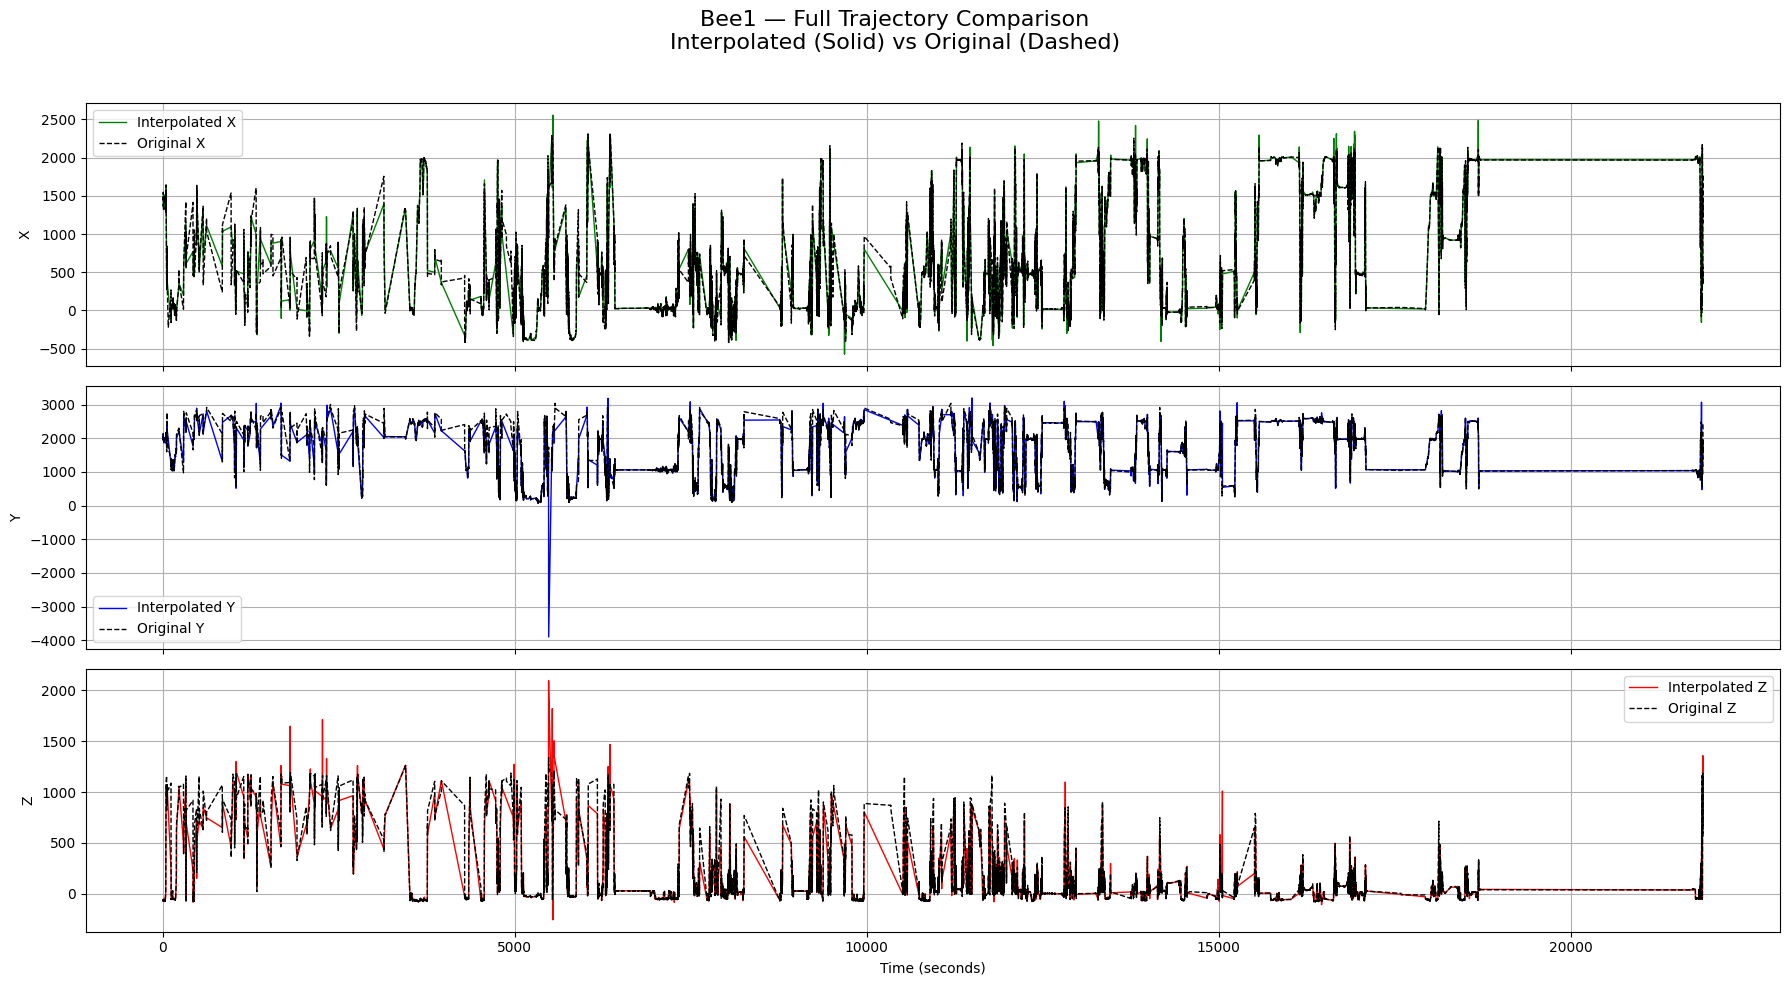

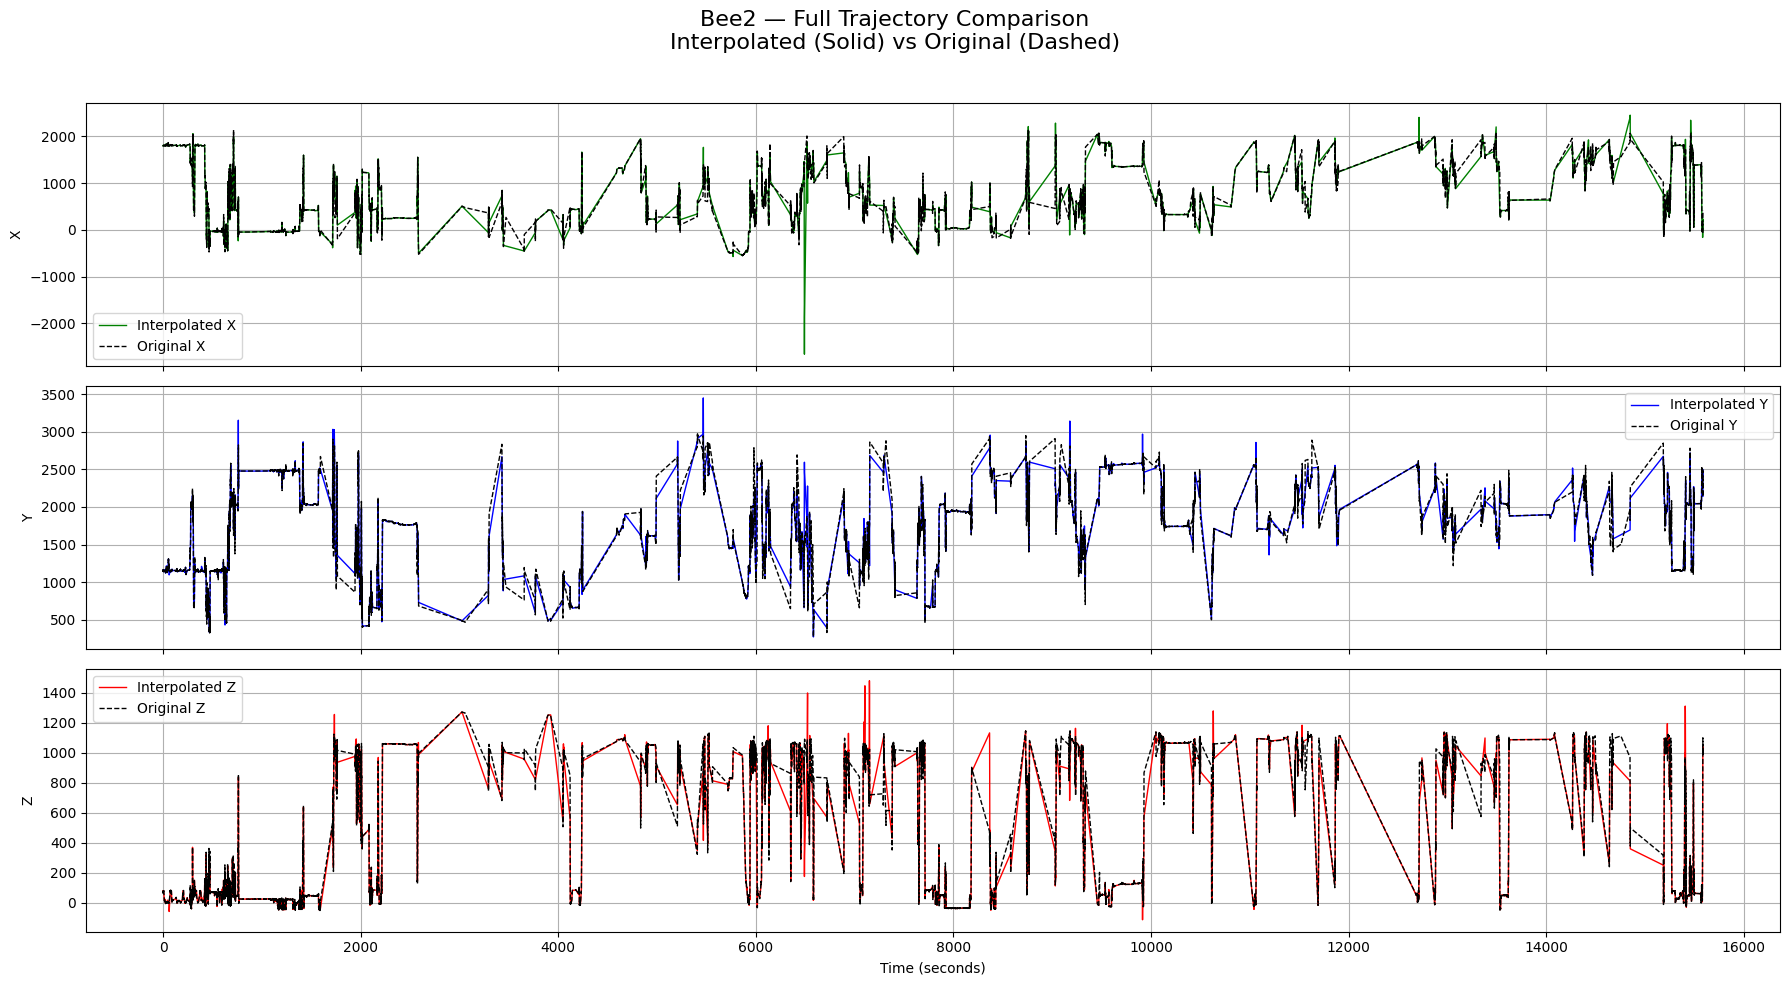

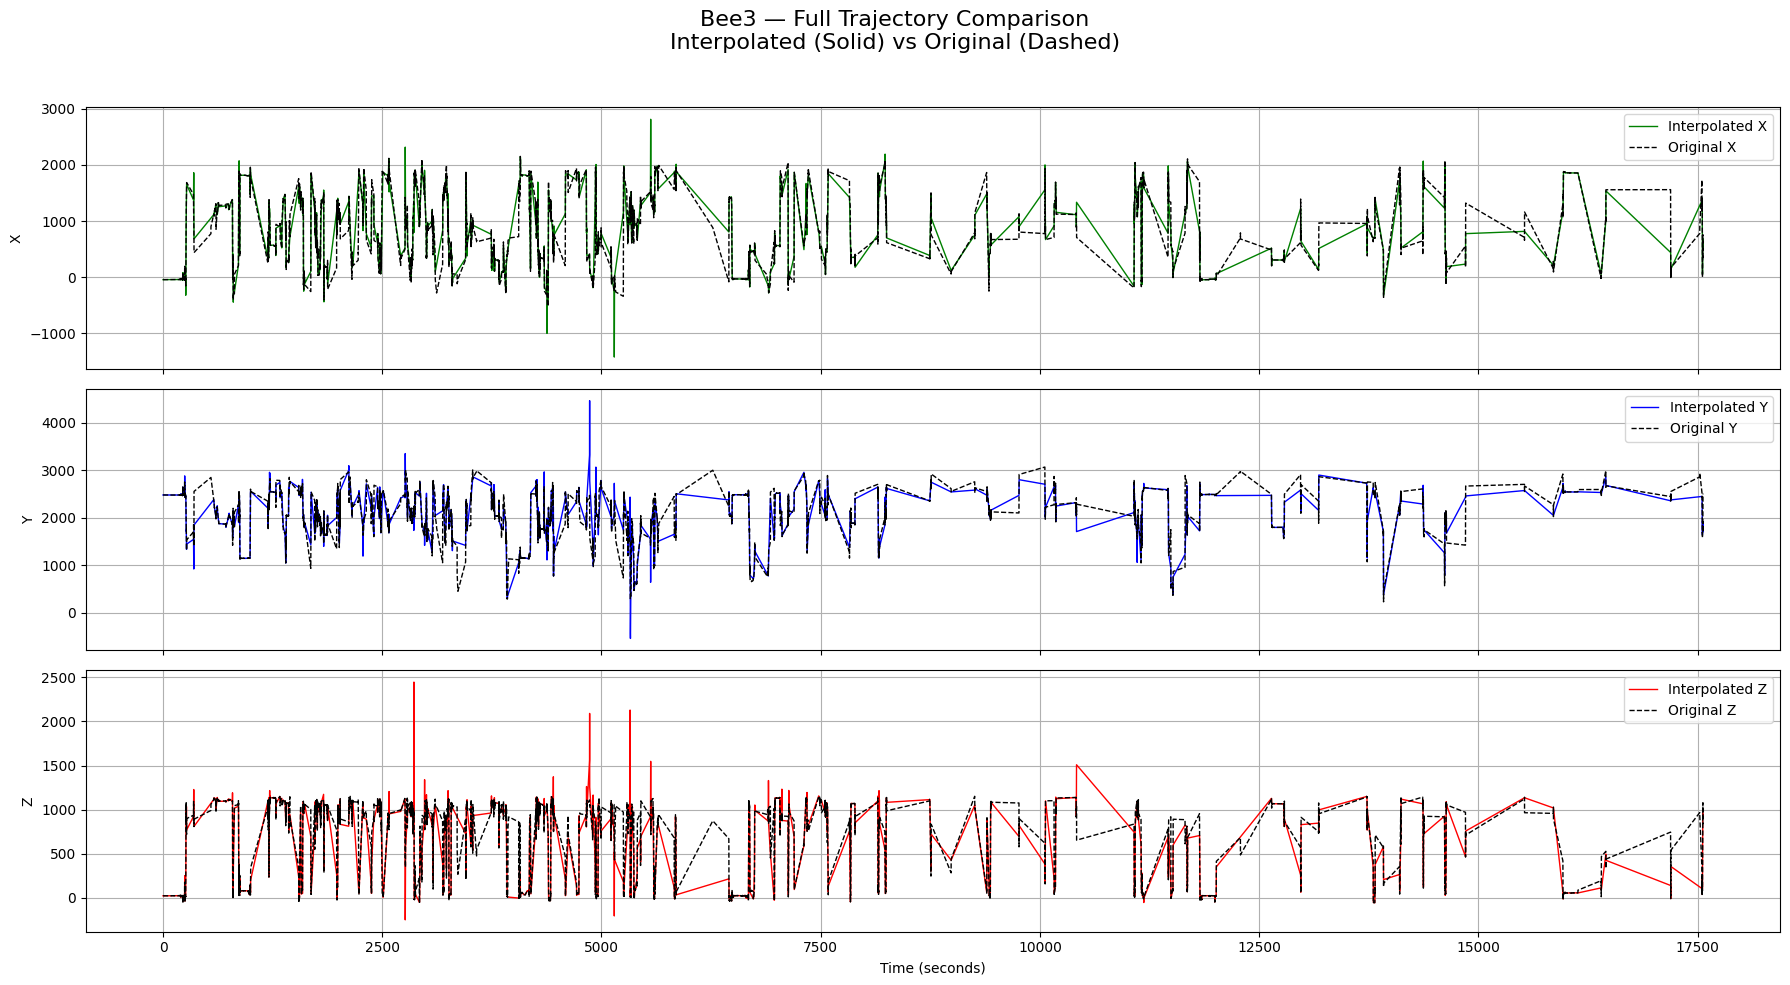

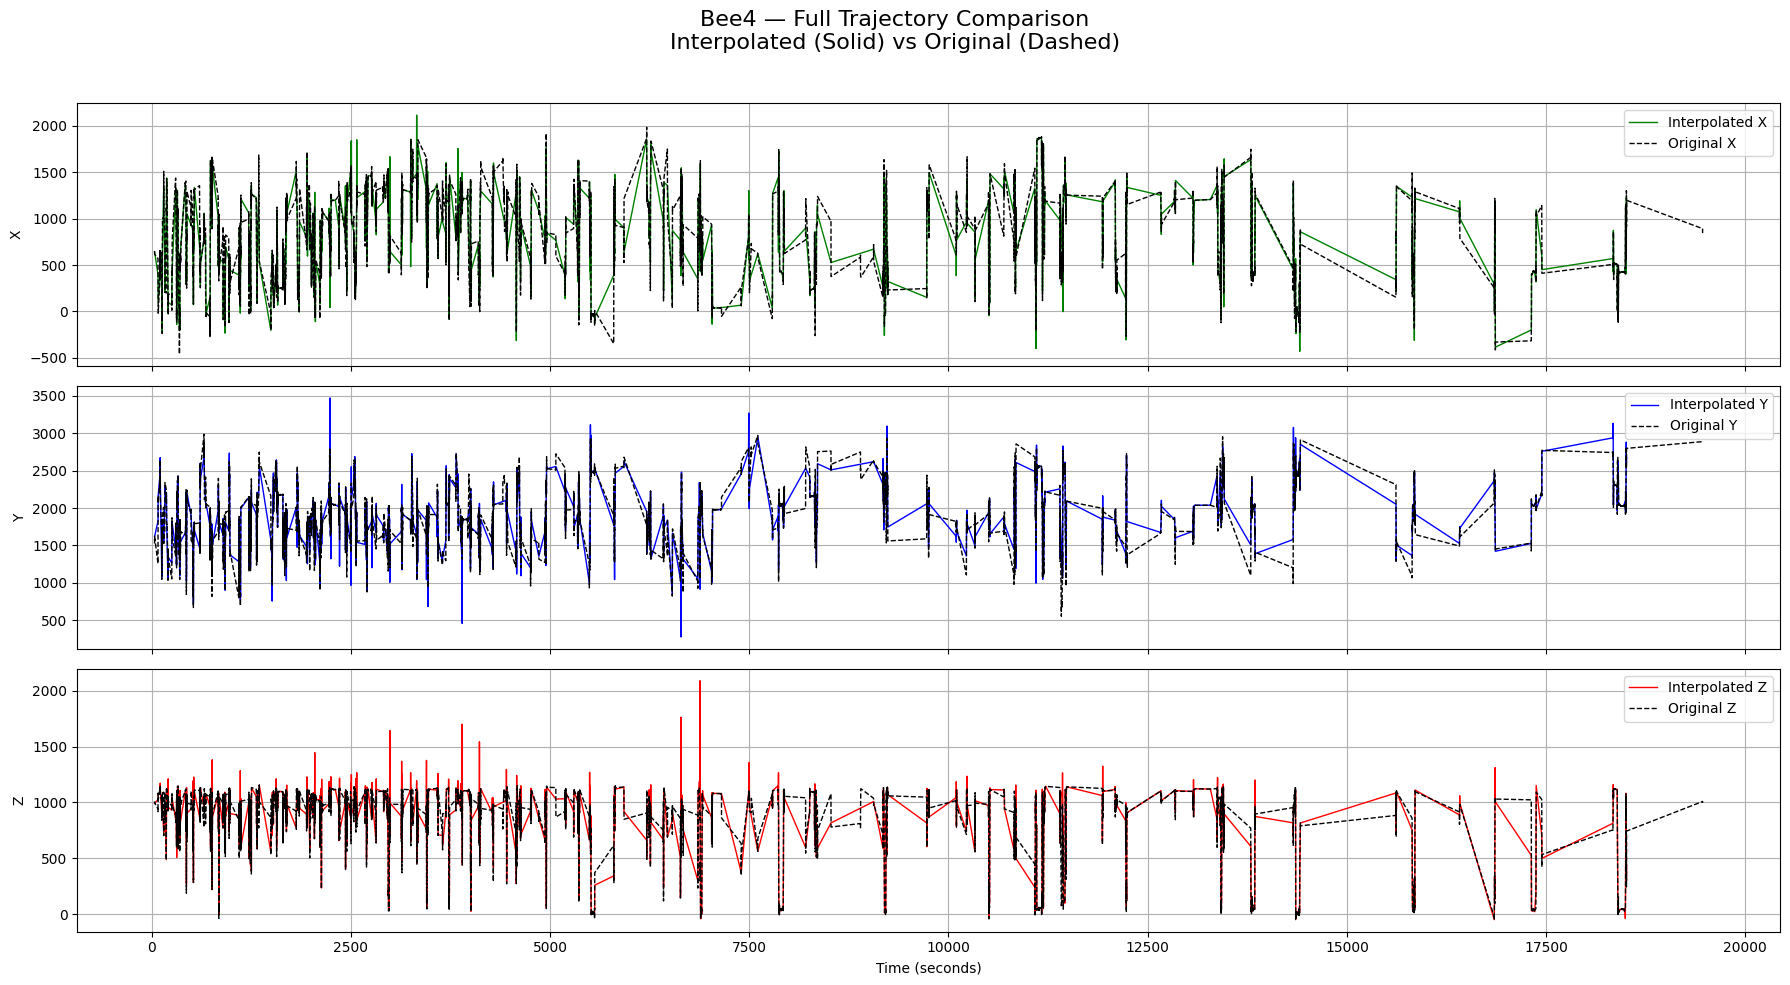

In [18]:
import matplotlib.pyplot as plt
import os

# Choose bees to plot
bees_to_plot = ['Bee1', 'Bee2', 'Bee3', 'Bee4']  # or use random.sample([...], 4)

for bee in bees_to_plot:
    # Load original file
    original_file = os.path.join('data_raw', f'{bee}.xlsx')
    df_orig = pd.read_excel(original_file)
    df_orig['fixed_time'] = fix_time_resets(df_orig['time'].values)
    df_orig = df_orig.dropna(subset=['x', 'y', 'z']).drop_duplicates(subset='fixed_time').sort_values('fixed_time')

    # Load interpolated data
    df_interp = df_merged[df_merged['bee_id'] == bee]
    df_interp_downsampled = df_interp.iloc[::30]  # downsample to ~1Hz for readability

    # Plot X, Y, Z in subplots
    fig, axes = plt.subplots(3, 1, figsize=(18, 10), sharex=True)

    axes[0].plot(df_interp_downsampled['time'], df_interp_downsampled['x'], color='green', label='Interpolated X', linewidth=1)
    axes[0].plot(df_orig['fixed_time'], df_orig['x'], color='black', linestyle='--', label='Original X', linewidth=1)
    axes[0].set_ylabel("X")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(df_interp_downsampled['time'], df_interp_downsampled['y'], color='blue', label='Interpolated Y', linewidth=1)
    axes[1].plot(df_orig['fixed_time'], df_orig['y'], color='black', linestyle='--', label='Original Y', linewidth=1)
    axes[1].set_ylabel("Y")
    axes[1].legend()
    axes[1].grid(True)

    axes[2].plot(df_interp_downsampled['time'], df_interp_downsampled['z'], color='red', label='Interpolated Z', linewidth=1)
    axes[2].plot(df_orig['fixed_time'], df_orig['z'], color='black', linestyle='--', label='Original Z', linewidth=1)
    axes[2].set_ylabel("Z")
    axes[2].set_xlabel("Time (seconds)")
    axes[2].legend()
    axes[2].grid(True)

    fig.suptitle(f"{bee} — Full Trajectory Comparison\nInterpolated (Solid) vs Original (Dashed)", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
